# paper_riskDD — 02: Probit Model Results

Results section structure:

1. **Non-symbolic format** (model-2rem2): γ and indifference point by group × stake size
2. **Symbolic format** (model-2rem1): same, with stake-size × group interaction as main focus
3. **Both formats combined** (model-3rem1): format × stake-size × group
4. **Cognitive model results** *(placeholder — structure only)*
5. **Convergent evidence**: eyetracking by group; correlations with companion-paper measures

**Exclusions:** subjects {32, 40, 45, 46, 50} removed for **both** formats.

**Indifference point** = `−intercept / γ`  (log-ratio where P(chose risky) = 0.5).
Risk-neutral reference: `log(1/0.55) ≈ 0.598`.

**Output files**
- `results/probit_posterior_effects.csv`   — fixed-effect parameter posteriors
- `results/probit_indpoint_effects.csv`    — ind_point-derived effects for model-3rem1
- `results/probit_{fmt}_subwise_ss_indpoint_slope.csv`
- `results/convergent_correlations.csv`
- `figures/` — all paper figures

In [16]:
import sys, os, os.path as op
from itertools import product
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import bambi
import arviz as az

from numrisk.behavior_risk.utils import get_data, extract_rnp_precision, invprobit
sys.path.insert(0, os.getcwd())
from utils_riskBehav import summarize_posterior, save_posterior_effects, save_indpoint_effects

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.2)
pal = {'Control': sns.color_palette()[0], 'Dyscalculic': sns.color_palette()[1]}
GROUP_COLORS = {0: pal['Control'], 1: pal['Dyscalculic']}

# ind_point = -intercept/gamma; risk-neutral = log(1/0.55)
IND_NEUTRAL = -np.log(0.55)

bids_folder      = '/Users/mrenke/data/ds-dnumrisk'
trace_folder     = op.join(bids_folder, 'derivatives', 'cogmodels_risk')
phenotype_folder = op.join(bids_folder, 'derivatives', 'phenotype')
out_folder       = op.join(bids_folder, 'plots_and_ims', 'paper_riskDD')
figures_folder   = op.join(out_folder, 'figures')
results_folder   = op.join(out_folder, 'results')
main_effect_scv      = op.join(results_folder, 'probit_posterior_effects.csv')
indpoint_csv = op.join(results_folder, 'probit_indpoint_effects.csv')

for d in [figures_folder, results_folder]:
    os.makedirs(d, exist_ok=True)

EXCLUDED = [32, 40, 45, 46, 50]  # same for both formats
FORMULA_2 = 'chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)'

print('Setup complete.')

Setup complete.


In [17]:
df = get_data()
df['x'] = df['log(risky/safe)']

groupList = df[['group']].groupby('subject').first().astype(int)
groupList['group_label'] = groupList['group'].map({0: 'Control', 1: 'Dyscalculic'})

df_sym    = df.xs('symbolic',     level='format').loc[~df.xs('symbolic',     level='format').index.get_level_values('subject').isin(EXCLUDED)]
df_nonsym = df.xs('non-symbolic', level='format').loc[~df.xs('non-symbolic', level='format').index.get_level_values('subject').isin(EXCLUDED)]
df_rem1   = df.loc[~df.index.get_level_values('subject').isin(EXCLUDED)]

print(f'Excluded:                {EXCLUDED}')
print(f'Symbolic N subjects:     {df_sym.index.unique("subject").nunique()}')
print(f'Non-symbolic N subjects: {df_nonsym.index.unique("subject").nunique()}')
print(f'Both-format N subjects:  {df_rem1.index.unique("subject").nunique()}')

number of subjects in dataframe: 66
Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
       55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
      dtype='int64', name='subject')
Excluded:                [32, 40, 45, 46, 50]
Symbolic N subjects:     61
Non-symbolic N subjects: 61
Both-format N subjects:  61


### Helper: extract γ and ind_point from a single-format model

In [18]:
def extract_ind_point(trace, model, data_fmt, group_level=False):
    """Return (intercept, gamma, ind_long, gamma_long) as long-format DataFrames.

    ind_point = -intercept / gamma  (log-ratio where P(chose risky) = 0.5)
    """
    intercept, gamma = extract_rnp_precision(
        trace, model, data_fmt, format=False, group_level=group_level
    )
    ind = -intercept / gamma

    ind_long   = ind.stack([1, 2]).rename(columns={'chose_risky_mean': 'ind_point'})
    gamma_long = gamma.stack([1, 2]).rename(columns={'chose_risky_mean': 'gamma'})
    int_long   = intercept.stack([1, 2]).rename(columns={'chose_risky_mean': 'intercept'})

    # attach group label
    for df_long in [ind_long, gamma_long, int_long]:
        df_long['group_label'] = df_long.index.get_level_values('group').map(
            {0: 'Control', 1: 'Dyscalculic'}
        )
    return intercept, gamma, ind_long, gamma_long


def subwise_ss_slope(param_long, col, groupList):
    """Fit ind_point ~ n_safe per subject, return DataFrame of MAP slopes."""
    # mean over posterior samples
    maps = (
        param_long.groupby(['subject', 'group', 'n_safe'])[col]
        .mean().reset_index()
    )
    slopes = {}
    for sub, sd in maps.groupby('subject'):
        sd = sd.sort_values('n_safe')
        A  = np.vstack([sd['n_safe'], np.ones(len(sd))]).T
        slope, _ = np.linalg.lstsq(A, sd[col].values, rcond=None)[0]
        slopes[sub] = slope
    return (
        pd.Series(slopes, name='ss_slope')
        .rename_axis('subject').to_frame()
        .join(groupList['group_label'])
    )


def print_key_effects(main_effect_scv, model_name, key_effects):
    df_eff = pd.read_csv(main_effect_scv)
    df_m   = df_eff[df_eff['model'] == model_name]
    print(f'=== {model_name}: key fixed-effect posteriors ===')
    for eff in key_effects:
        row = df_m[df_m['effect'] == eff]
        if len(row):
            r = row.iloc[0]
            sign_str = f"P(>0)={r['p_gt_0']:.3f}" if r['mean'] >= 0 else f"P(<0)={1-r['p_gt_0']:.3f}"
            print(f"  {eff:30s}: M={r['mean']:+.3f}, 95%CI=[{r['ci_low']:+.3f}, {r['ci_high']:+.3f}], {sign_str}")
# per-subject MAPs (mean over posterior)
def maps_by_sub(long_df, col):
    m = long_df.groupby(['subject', 'group', 'n_safe'])[col].mean().reset_index()
    m['group_label'] = m['group'].map({0: 'Control', 1: 'Dyscalculic'})
    return m

print('Helpers defined.')

Helpers defined.


---
## 2.1 Non-Symbolic Format — model-2rem1

Formula: `chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)`

Trace: `probit_model-2rem1_format-non-symbolic_trace.netcdf`

Exclusions: {32, 40, 45, 46, 50} — same 5 subjects as symbolic.

*(Note: model-2rem2 exists but removes only {40, 46, 50}; we use 2rem1 for consistent exclusions.)*

In [23]:
trace_ns = az.from_netcdf(
    op.join(trace_folder, 'probit_model-2rem1_format-non-symbolic_trace.netcdf')
)
model_ns = bambi.Model(
    FORMULA_2, link='probit', family='bernoulli', data=df_nonsym.reset_index()
)
print('Non-symbolic trace loaded.')
print('Fixed-effect vars:', [v for v in trace_ns.posterior.data_vars if 'subject' not in v])

Non-symbolic trace loaded.
Fixed-effect vars: ['Intercept', 'x', 'group', 'x:group', 'n_safe', 'x:n_safe', 'group:n_safe', 'x:group:n_safe']


In [24]:
# Save parameters: effects & subwise slopes
save_posterior_effects(trace_ns, model_name="2rem1_non-symbolic", csv_path=main_effect_scv)

# group_level=True  → population-level posteriors for group effects
# group_level=False → subject-specific posteriors for per-subject subwise slopes
_, _, ind_ns,     gamma_ns     = extract_ind_point(trace_ns, model_ns, df_nonsym, group_level=True)
_, _, ind_ns_sub, gamma_ns_sub = extract_ind_point(trace_ns, model_ns, df_nonsym, group_level=False)

df_ss_nonsym = subwise_ss_slope(ind_ns_sub, "ind_point", groupList)
df_ss_nonsym.to_csv(op.join(results_folder, "probit_nonsym_subwise_ss_indpoint_slope.csv"))

save_indpoint_effects(ind_ns, model_name="2rem1_non-symbolic", csv_path=indpoint_csv)


Saved 12 parameters for '2rem1_non-symbolic' → /Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_riskDD/results/probit_posterior_effects.csv


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_6317/2962210635.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ind_long   = ind.stack([1, 2]).rename(columns={'chose_risky_mean': 'ind_point'})
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_6317/2962210635.py:12: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify futu

Saved 4 effects for '2rem1_non-symbolic' → /Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_riskDD/results/probit_indpoint_effects.csv


,model,effect,mean,ci_low,ci_high,p_gt_0
0,2rem1_non-symbolic,ind_point,0.967223,0.733323,1.227379,1.000
1,2rem1_non-symbolic,ind_point:group,0.041975,-0.273689,0.359217,0.604
2,2rem1_non-symbolic,ind_point:SS,-0.003418,-0.009606,0.003792,0.150
3,2rem1_non-symbolic,ind_point:SS:group,-0.005104,-0.014728,0.004361,0.145


### Plot: γ and indifference point by group × stake size (non-symbolic)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/relational.py:292: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data = grouped.apply(agg, other).reset_index()
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tu

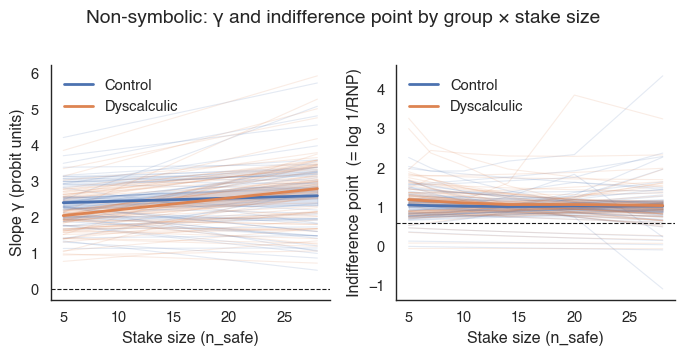

Figure saved.


In [ ]:
# per-subject maps (group_level=False) for thin individual lines
ind_ns_maps   = maps_by_sub(ind_ns_sub,   "ind_point")
gamma_ns_maps = maps_by_sub(gamma_ns_sub, "gamma")
# population-level maps (group_level=True) for thick group lines
ind_ns_grp   = maps_by_sub(ind_ns,   "ind_point")
gamma_ns_grp = maps_by_sub(gamma_ns, "gamma")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, df_sub, df_grp, yvar, ylabel, ref_y in zip(
    axs,
    [gamma_ns_maps, ind_ns_maps],
    [gamma_ns_grp,  ind_ns_grp],
    ["gamma", "ind_point"],
    ["Slope γ (probit units)", "Indifference point  (= log 1/RNP)"],
    [0,         IND_NEUTRAL]
):
    for grp_label, grp_data in df_sub.groupby("group_label"):
        for sub, sd in grp_data.groupby("subject"):
            ax.plot(sd["n_safe"], sd[yvar], color=pal[grp_label], alpha=0.15, lw=0.8)
    sns.lineplot(data=df_grp, x="n_safe", y=yvar, hue="group_label",
                 palette=pal, errorbar=("ci", 95), lw=2, ax=ax)
    ax.axhline(ref_y, color="k", lw=0.8, ls="--")
    ax.set(xlabel="Stake size (n_safe)", ylabel=ylabel)
    ax.legend(title="", frameon=False)
    sns.despine(ax=ax)

plt.suptitle("Non-symbolic: γ and indifference point by group × stake size", y=1.01)
plt.tight_layout()
fig.savefig(op.join(figures_folder, "nonsym_gamma_indpoint_by_nsafe_group.pdf"), bbox_inches="tight")
plt.show()
print("Figure saved.")


---
## 2.2 Symbolic Format — model-2rem1

Formula: `chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)`

Trace: `probit_model-2rem1_format-symbolic_trace.netcdf`

Exclusions: {32, 40, 45, 46, 50}

**Main focus: stake-size × group interaction on indifference point** (H1b).

In [19]:
trace_s = az.from_netcdf(
    op.join(trace_folder, "probit_model-2rem1_format-symbolic_trace.netcdf")
)
model_s = bambi.Model(FORMULA_2, link="probit", family="bernoulli", data=df_sym.reset_index())
print("Symbolic trace loaded.")
print("Fixed-effect vars:", [v for v in trace_s.posterior.data_vars if "subject" not in v])

# group_level=True  → population-level posteriors for group effects
# group_level=False → subject-specific posteriors for per-subject subwise slopes
_, _, ind_s,     gamma_s     = extract_ind_point(trace_s, model_s, df_sym, group_level=True)
_, _, ind_s_sub, gamma_s_sub = extract_ind_point(trace_s, model_s, df_sym, group_level=False)

ind_s_maps   = maps_by_sub(ind_s_sub,   "ind_point")
gamma_s_maps = maps_by_sub(gamma_s_sub, "gamma")


Symbolic trace loaded.
Fixed-effect vars: ['Intercept', 'x', 'group', 'x:group', 'n_safe', 'x:n_safe', 'group:n_safe', 'x:group:n_safe']


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_8539/2962210635.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ind_long   = ind.stack([1, 2]).rename(columns={'chose_risky_mean': 'ind_point'})
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_8539/2962210635.py:12: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify futu

In [5]:
#save parameters: effects & subwise slopes
save_posterior_effects(trace_s, model_name="2rem1_symbolic", csv_path=main_effect_scv)

df_ss_sym = subwise_ss_slope(ind_s_sub, "ind_point", groupList)
df_ss_sym.to_csv(op.join(results_folder, "probit_sym_subwise_ss_indpoint_slope.csv"))

# save group-level ind_point effects (no format level — single-format model)
save_indpoint_effects(ind_s, model_name="2rem1_symbolic", csv_path=indpoint_csv)


Saved 12 parameters for '2rem1_symbolic' → /Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_riskDD/results/probit_posterior_effects.csv
Saved 4 effects for '2rem1_symbolic' → /Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_riskDD/results/probit_indpoint_effects.csv


,model,effect,mean,ci_low,ci_high,p_gt_0
0,2rem1_symbolic,ind_point,0.960312,0.552844,1.393359,1.000
1,2rem1_symbolic,ind_point:group,0.077936,-0.190688,0.392045,0.687
2,2rem1_symbolic,ind_point:SS,-0.021271,-0.026374,-0.016887,0.000
3,2rem1_symbolic,ind_point:SS:group,-0.008392,-0.016606,-0.000774,0.017


### Plot: γ and indifference point by group × stake size (symbolic)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/relational.py:292: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data = grouped.apply(agg, other).reset_index()
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tu

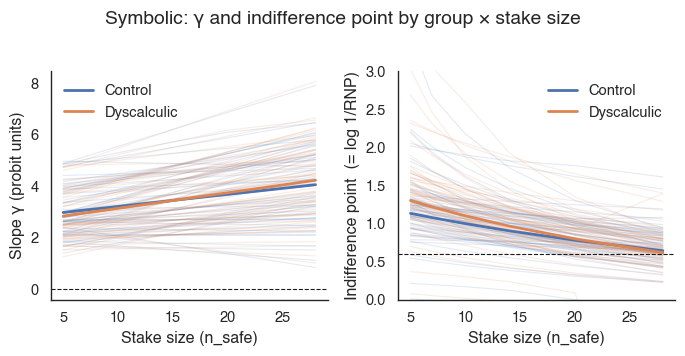

Figure saved.


In [25]:
# per-subject maps (group_level=False) for thin individual lines
ind_s_maps   = maps_by_sub(ind_s_sub,   "ind_point")
gamma_s_maps = maps_by_sub(gamma_s_sub, "gamma")
# population-level maps (group_level=True) for thick group lines
ind_s_grp   = maps_by_sub(ind_s,   "ind_point")
gamma_s_grp = maps_by_sub(gamma_s, "gamma")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, df_sub, df_grp, yvar, ylabel, ref_y in zip(
    axs,
    [gamma_s_maps, ind_s_maps],
    [gamma_s_grp,  ind_s_grp],
    ["gamma", "ind_point"],
    ["Slope γ (probit units)", "Indifference point  (= log 1/RNP)"],
    [0,         IND_NEUTRAL]
):
    for grp_label, grp_data in df_sub.groupby("group_label"):
        for sub, sd in grp_data.groupby("subject"):
            ax.plot(sd["n_safe"], sd[yvar], color=pal[grp_label], alpha=0.15, lw=0.8)
    sns.lineplot(data=df_grp, x="n_safe", y=yvar, hue="group_label",
                 palette=pal, errorbar=("ci", 95), lw=2, ax=ax)
    ax.axhline(ref_y, color="k", lw=0.8, ls="--")
    ax.set(xlabel="Stake size (n_safe)", ylabel=ylabel)
    ax.legend(title="", frameon=False)
    sns.despine(ax=ax)
axs[1].set(ylim=(0, 3))
plt.suptitle("Symbolic: γ and indifference point by group × stake size", y=1.01)
plt.tight_layout()
fig.savefig(op.join(figures_folder, "sym_gamma_indpoint_by_nsafe_group.pdf"), bbox_inches="tight")
plt.show()
print("Figure saved.")


### H1b: ind_point × stake-size × group — posterior slope distributions

For each posterior sample, fit `ind_point ~ n_safe` per group.
Report the general slope and the group difference (Dyscalculic − Control).

In [20]:
# ind_s uses group_level=True → population-level posteriors (correct for group slope comparison)
n_chains = ind_s.index.unique("chain").values
n_draws  = ind_s.index.unique("draw").values
idx      = pd.MultiIndex.from_product([n_chains, n_draws], names=["chain", "draw"])

df_slopes = pd.DataFrame(index=idx, columns=["main_diff", "slope_ctrl", "slope_dysc"], dtype=float)

for chain, draw in product(n_chains, n_draws):
    sample = ind_s.xs(chain, level="chain").xs(draw, level="draw").reset_index()
    # main group effect: mean ind_point Dysc − Ctrl (marginalised over n_safe)
    df_slopes.loc[(chain, draw), "main_diff"] = (
        sample[sample["group"] == 1]["ind_point"].mean()
        - sample[sample["group"] == 0]["ind_point"].mean()
    )
    for grp_idx, key in [(0, "ctrl"), (1, "dysc")]:
        tmp   = sample[sample["group"] == grp_idx]
        A     = np.vstack([tmp["n_safe"], np.ones(len(tmp))]).T
        slope, _ = np.linalg.lstsq(A, tmp["ind_point"].values, rcond=None)[0]
        df_slopes.loc[(chain, draw), f"slope_{key}"] = slope

df_slopes["slope_general"] = (df_slopes["slope_ctrl"] + df_slopes["slope_dysc"]) / 2
df_slopes["slope_diff"]    =  df_slopes["slope_dysc"] - df_slopes["slope_ctrl"]  # Dysc − Ctrl

for col, label in [("main_diff", "Dysc − Control (main)"),
                    ("slope_general", "general slope"),
                    ("slope_diff", "Dysc − Control (SS interaction)")]:
    s     = summarize_posterior(df_slopes[col])
    p_neg = np.mean(df_slopes[col] < 0)
    print(f"ind_point [{label}]:  M={s['mean']:+.4f}, CI=[{s['ci_low']:+.4f}, {s['ci_high']:+.4f}],  P(<0)={p_neg:.3f}")


ind_point [Dysc − Control (main)]:  M=+0.0779, CI=[-0.1683, +0.3340],  P(<0)=0.272
ind_point [general slope]:  M=-0.0255, CI=[-0.0298, -0.0216],  P(<0)=1.000
ind_point [Dysc − Control (SS interaction)]:  M=-0.0084, CI=[-0.0166, -0.0008],  P(<0)=0.983


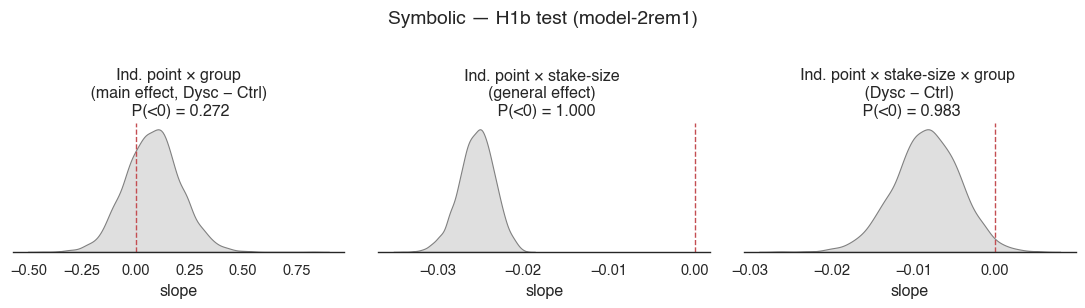

Figure saved.


In [23]:
panels = {"main_diff":    ("Ind. point × group\n (main effect, Dysc − Ctrl)", "grey"),
    "slope_general": ("Ind. point × stake-size \n(general effect)",   "grey"),
    "slope_diff":    ("Ind. point × stake-size × group \n (Dysc − Ctrl)",  "grey"),}

fig, axs = plt.subplots(1, 3, figsize=(11, 3))
for ax, (col, (title, color)) in zip(axs, panels.items()):
    p_neg = np.mean(df_slopes[col] < 0)
    sns.kdeplot(df_slopes[col], fill=True, ax=ax, color=color)
    ax.axvline(0, color="r", ls="--", lw=1)
    ax.set_title(f"{title} \n P(<0) = {p_neg:.3f}")
    ax.set(yticks=[], ylabel="", xlabel="slope")
    sns.despine(ax=ax, left=True)

fig.suptitle(f"Symbolic — H1b test (model-2rem1)", y=1.02)
plt.tight_layout()
fig.savefig(op.join(figures_folder, "sym_h1b_indpoint_ss_slopes.pdf"), bbox_inches="tight")
plt.show()
print("Figure saved.")


### H2 / H1a: γ fixed-effect terms (from trace directly)

- `x:group`       — H1a: overall gamma group difference
- `x:n_safe`      — gamma × stake size (general)
- `x:group:n_safe` — H2: gamma × SS × group

x:group: M=-0.2099, CI=[-0.8971,+0.4694], P(>0)=0.267
x:n_safe: M=+0.0468, CI=[+0.0221,+0.0724], P(>0)=1.000
x:group:n_safe: M=+0.0137, CI=[-0.0243,+0.0495], P(>0)=0.770


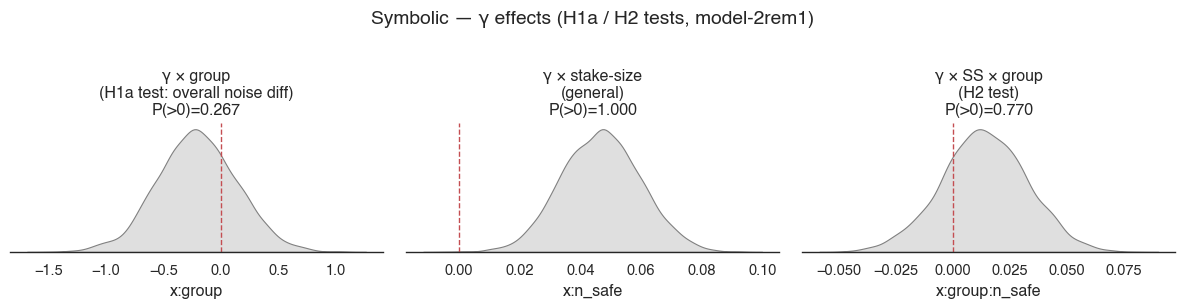

Figure saved.


In [ ]:
panels_gamma = {'x:group':       ('γ × group\n(H1a test: overall noise diff)',   'grey'),
    'x:n_safe':      ('γ × stake-size\n(general)',                    'grey'),
    'x:group:n_safe':('γ × SS × group\n(H2 test)',                    'grey'),}

fig, axs = plt.subplots(1, len(panels_gamma), figsize=(4*len(panels_gamma), 3))
for ax, (var, (title, color)) in zip(axs, panels_gamma.items()):
    if var not in trace_s.posterior.data_vars:
        ax.set_visible(False)
        continue
    vals = trace_s.posterior[var].values.ravel()
    p_pos = np.mean(vals > 0)
    s = summarize_posterior(vals)
    sns.kdeplot(vals, fill=True, ax=ax, color=color)
    ax.axvline(0, color='r', ls='--', lw=1)
    ax.set_title(f'{title}\nP(>0)={p_pos:.3f}')
    ax.set(yticks=[], ylabel='', xlabel=var)
    sns.despine(ax=ax, left=True)
    print(f'{var}: M={s["mean"]:+.4f}, CI=[{s["ci_low"]:+.4f},{s["ci_high"]:+.4f}], P(>0)={p_pos:.3f}')

fig.suptitle('Symbolic — γ effects (H1a / H2 tests, model-2rem1)', y=1.02)
plt.tight_layout()
fig.savefig(op.join(figures_folder, 'sym_gamma_h1a_h2_effects.pdf'), bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 2.3 Both Formats Combined — model-3rem1

Formula: `chose_risky ~ x + x*group*format*n_safe + (x*format*n_safe|subject)`

Trace: `probit_model-3rem1_format-both_trace.netcdf`

Exclusions: {32, 40, 45, 46, 50}

In [ ]:
trace_b = az.from_netcdf(
    op.join(trace_folder, 'probit_model-3rem1_format-both_trace.netcdf')
)
model_b = bambi.Model(
    'chose_risky ~ x + x*group*format*n_safe + (x*format*n_safe|subject)',
    link='probit', family='bernoulli', data=df_rem1.reset_index()
)
print('Both-format trace loaded.')
print('Fixed-effect vars:', [v for v in trace_b.posterior.data_vars if 'subject' not in v])

In [ ]:
save_posterior_effects(trace_b, model_name='3rem1_both', csv_path=main_effect_scv)

KEY_EFF_3 = ['x', 'x:group', 'x:n_safe', 'x:group:n_safe',
             'x:format', 'x:group:format', 'x:group:format:n_safe']
print_key_effects(main_effect_scv, '3rem1_both', KEY_EFF_3)

In [ ]:
# extract_rnp_precision with format=True returns index with 'format' level
intercept_b, gamma_b = extract_rnp_precision(
    trace_b, model_b, df_rem1, format=True, group_level=True
)
ind_b = -intercept_b / gamma_b

ind_b_long   = ind_b.stack([1, 2]).rename(columns={'chose_risky_mean': 'ind_point'})
gamma_b_long = gamma_b.stack([1, 2]).rename(columns={'chose_risky_mean': 'gamma'})

for df_long in [ind_b_long, gamma_b_long]:
    df_long['group_label'] = df_long.index.get_level_values('group').map(
        {0: 'Control', 1: 'Dyscalculic'}
    )

print('Index levels:', ind_b_long.index.names)

In [ ]:
# save ind_point effects for both-format model (has format level → includes format contrasts)
df_indeff = save_indpoint_effects(
    ind_b_long, model_name='3rem1_both', csv_path=indpoint_csv
)

print('=== ind_point effects (model 3rem1, both formats) ===')
print(df_indeff.to_string(index=False))

### Plot: indifference point by group × format × stake size

In [ ]:
df_ind_maps_b = (
    ind_b_long
    .groupby(['subject', 'group', 'format', 'n_safe'])['ind_point']
    .mean().reset_index()
)
df_ind_maps_b['group_label'] = df_ind_maps_b['group'].map({0: 'Control', 1: 'Dyscalculic'})

g = sns.FacetGrid(
    df_ind_maps_b, col='format', hue='group_label',
    palette=pal, height=3.5, aspect=1.1
)
g.map_dataframe(sns.lineplot, x='n_safe', y='ind_point', errorbar=('ci', 95), lw=2)
g.add_legend(title='')
for ax in g.axes.flatten():
    ax.axhline(IND_NEUTRAL, color='k', lw=0.8, ls='--', label=f'risk-neutral ({IND_NEUTRAL:.2f})')
    ax.set(xlabel='Stake size (n_safe)', ylabel='Indifference point  (= log 1/RNP)')
    sns.despine(ax=ax)
g.figure.suptitle('Indifference point by group × format × stake size (model 3rem1)', y=1.02)
g.figure.savefig(op.join(figures_folder, 'both_indpoint_by_format_nsafe_group.pdf'), bbox_inches='tight')
plt.show()
print('Figure saved.')